In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Advertising.csv")

In [3]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
X = df.drop('sales', axis=1)

In [5]:
y=df['sales']

In [6]:
from sklearn.preprocessing import PolynomialFeatures

In [7]:
Polynomial_convertor = PolynomialFeatures(degree=2, include_bias=False)

In [8]:
Polynomial_convertor.fit(X)

,degree,2
,interaction_only,False
,include_bias,False
,order,'C'


In [13]:
poly_features = Polynomial_convertor.transform(X)

In [14]:
X.shape

(200, 3)

In [16]:
X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [ ]:
poly_features[0] #it has nine terms, first 3 are the original terms, then 3 possible interaction terms, and 3 possible square terms
#basically expended 3 features to 9 terms

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [20]:
Polynomial_convertor.fit_transform(X)

array([[ 230.1 ,   37.8 ,   69.2 , ..., 1428.84, 2615.76, 4788.64],
       [  44.5 ,   39.3 ,   45.1 , ..., 1544.49, 1772.43, 2034.01],
       [  17.2 ,   45.9 ,   69.3 , ..., 2106.81, 3180.87, 4802.49],
       ...,
       [ 177.  ,    9.3 ,    6.4 , ...,   86.49,   59.52,   40.96],
       [ 283.6 ,   42.  ,   66.2 , ..., 1764.  , 2780.4 , 4382.44],
       [ 232.1 ,    8.6 ,    8.7 , ...,   73.96,   74.82,   75.69]],
      shape=(200, 9))

In [23]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
#creating/dividing the data in the different sets for training and testing

In [28]:
from sklearn.linear_model import LinearRegression

In [31]:
model = LinearRegression()

In [32]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
test_predictions = model.predict(X_test)

In [34]:
model.coef_

array([ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02, -1.10892474e-04,
        1.14212673e-03, -5.24100082e-05,  3.34919737e-05,  1.46380310e-04,
       -3.04715806e-05])

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [36]:
MAE = mean_absolute_error(y_test, test_predictions)

In [37]:
MSE = mean_squared_error(y_test, test_predictions)

In [38]:
RMSE = np.sqrt(MSE)

In [39]:
MSE

0.44175055104033895

In [41]:
MAE

0.48967980448035886

In [40]:
RMSE

np.float64(0.6646431757269)

In [42]:
model.coef_

array([ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02, -1.10892474e-04,
        1.14212673e-03, -5.24100082e-05,  3.34919737e-05,  1.46380310e-04,
       -3.04715806e-05])

In [43]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [44]:
X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [45]:
69.2 ** 2

4788.64

In [ ]:
# creating the polynomial degree without accidently overfitting

# 1. Create the different order poly
# 2. Split poly feat train/test
# 3. Fit on the training data
# 4. Store/save the RMSE for both the training and test set. 
# 5. PLOT the results (error vs poly order)


In [50]:
train_rmse_errors =[]
test_rmse_errors = []

for d in range(1, 10):
    poly_convertor = PolynomialFeatures(degree=d, include_bias=False)
    poly_features = poly_convertor.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
    
    
    model=LinearRegression()
    model.fit(X_train, y_train)


    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)

    

In [51]:
train_rmse_errors

[np.float64(1.734594124329376),
 np.float64(0.5879574085292234),
 np.float64(0.43393443569020657),
 np.float64(0.35170836883993556),
 np.float64(0.2509342923789987),
 np.float64(0.20953728390810636),
 np.float64(0.220468592026013),
 np.float64(0.27150074924450723),
 np.float64(0.5132041534764078)]

In [57]:
test_rmse_errors

[np.float64(1.5161519375993877),
 np.float64(0.6646431757269),
 np.float64(0.5803286825219469),
 np.float64(0.5077742640851456),
 np.float64(2.575819388953378),
 np.float64(9.87141360632477),
 np.float64(41.33052004954889),
 np.float64(3108.5907535489564),
 np.float64(12767.649350485362)]

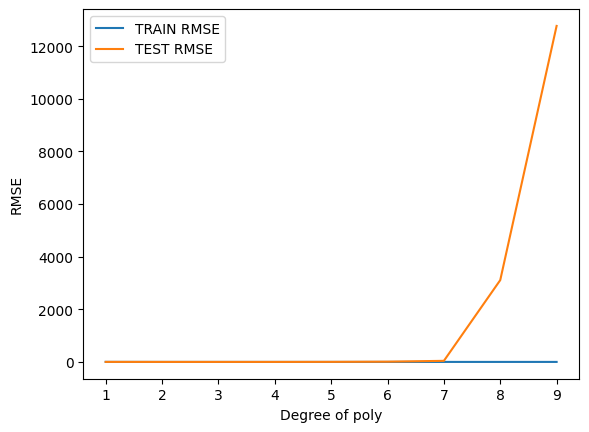

In [63]:
plt.plot(range(1, 10), train_rmse_errors, label="TRAIN RMSE")
plt.plot(range(1, 10), test_rmse_errors, label='TEST RMSE')



plt.xlabel('Degree of poly')
plt.ylabel('RMSE')
plt.legend()

In [64]:
final_poly_convertor = PolynomialFeatures(degree=3, include_bias=False)

In [67]:
final_model = LinearRegression()

In [69]:
full_converted_X = final_poly_convertor.fit_transform(X)
final_model.fit(full_converted_X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [70]:
from joblib import dump, load

In [71]:
dump(final_model, 'final_poly_model.joblib')

['final_poly_model.joblib']

In [72]:
dump(final_poly_convertor, 'final_convertor.joblib')

['final_convertor.joblib']

In [73]:
loaded_converter = load('final_convertor.joblib')
loadled_model = load('final_poly_model.joblib')

In [75]:
campaign = [[149, 23, 12]]

In [81]:
transformed_data = loaded_converter.fit_transform(campaign)

In [82]:
loadled_model.predict(transformed_data)

array([14.85050326])